In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\Samsung\OneDrive\Documentos\faculdade\Análise Exploratória de Mortalidade Infantil no Brasil\data\mortalidade_infantil_brasil.csv')
df.head()

,ano,estado,regiao,taxa_mortalidade_infantil
0,2010,Acre,Norte,22.20
1,2011,Acre,Norte,22.99
2,2012,Acre,Norte,21.87
3,2013,Acre,Norte,20.96
4,2014,Acre,Norte,19.31


In [2]:
print("Shape:", df.shape)
print("\nValores nulos:\n", df.isnull().sum())
print("\nEstatísticas gerais:")
df['taxa_mortalidade_infantil'].describe()

Shape: (378, 4)

Valores nulos:
 ano                          0
estado                       0
regiao                       0
taxa_mortalidade_infantil    0
dtype: int64

Estatísticas gerais:


count    378.000000
mean      16.578095
std        4.839857
min        8.070000
25%       12.312500
50%       16.370000
75%       20.322500
max       27.470000
Name: taxa_mortalidade_infantil, dtype: float64

In [5]:
import os
os.makedirs(r'C:\Users\Samsung\OneDrive\Documentos\faculdade\Análise Exploratória de Mortalidade Infantil no Brasil\imagens', exist_ok=True)
print("Pasta criada!")

Pasta criada!


regiao
Nordeste        20.70
Norte           18.60
Centro-Oeste    13.72
Sudeste         11.48
Sul             10.10
Name: taxa_mortalidade_infantil, dtype: float64


C:\Users\Samsung\AppData\Local\Temp\ipykernel_9552\3063275008.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_regiao.index, y=media_regiao.values, palette='Reds_r')


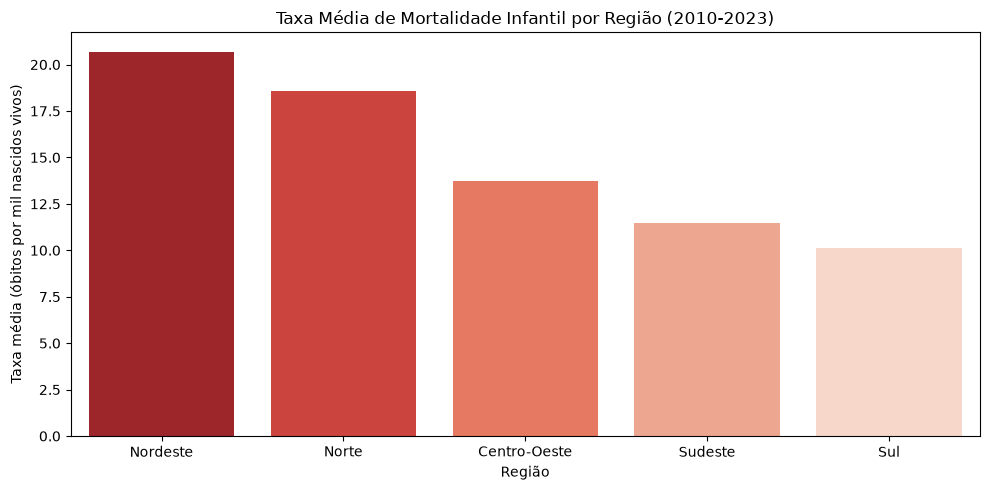

In [6]:
media_regiao = df.groupby('regiao')['taxa_mortalidade_infantil'].mean().sort_values(ascending=False).round(2)
print(media_regiao)

plt.figure(figsize=(10, 5))
sns.barplot(x=media_regiao.index, y=media_regiao.values, palette='Reds_r')
plt.title('Taxa Média de Mortalidade Infantil por Região (2010-2023)')
plt.xlabel('Região')
plt.ylabel('Taxa média (óbitos por mil nascidos vivos)')
plt.tight_layout()
plt.savefig(r'C:\Users\Samsung\OneDrive\Documentos\faculdade\Análise Exploratória de Mortalidade Infantil no Brasil\imagens\mortalidade_por_regiao.png')
plt.show()

In [7]:
import os
os.makedirs(r'C:\Users\Samsung\OneDrive\Documentos\faculdade\Análise Exploratória de Mortalidade Infantil no Brasil\imagens', exist_ok=True)
print("Pasta criada!")

Pasta criada!


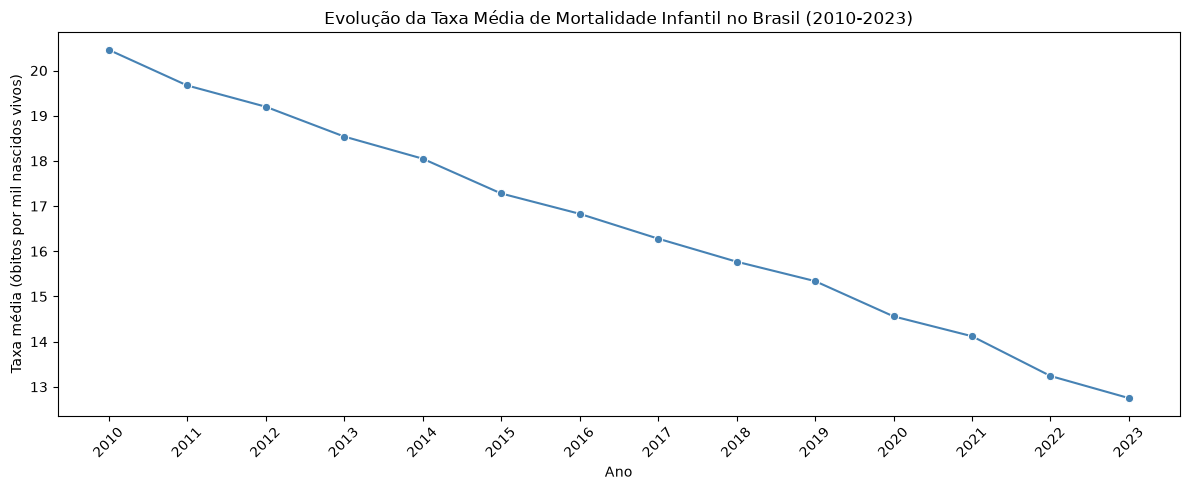

In [8]:
media_ano = df.groupby('ano')['taxa_mortalidade_infantil'].mean().round(2)

plt.figure(figsize=(12, 5))
sns.lineplot(x=media_ano.index, y=media_ano.values, marker='o', color='steelblue')
plt.title('Evolução da Taxa Média de Mortalidade Infantil no Brasil (2010-2023)')
plt.xlabel('Ano')
plt.ylabel('Taxa média (óbitos por mil nascidos vivos)')
plt.xticks(media_ano.index, rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\Samsung\OneDrive\Documentos\faculdade\Análise Exploratória de Mortalidade Infantil no Brasil\imagens\evolucao_nacional.png')
plt.show()

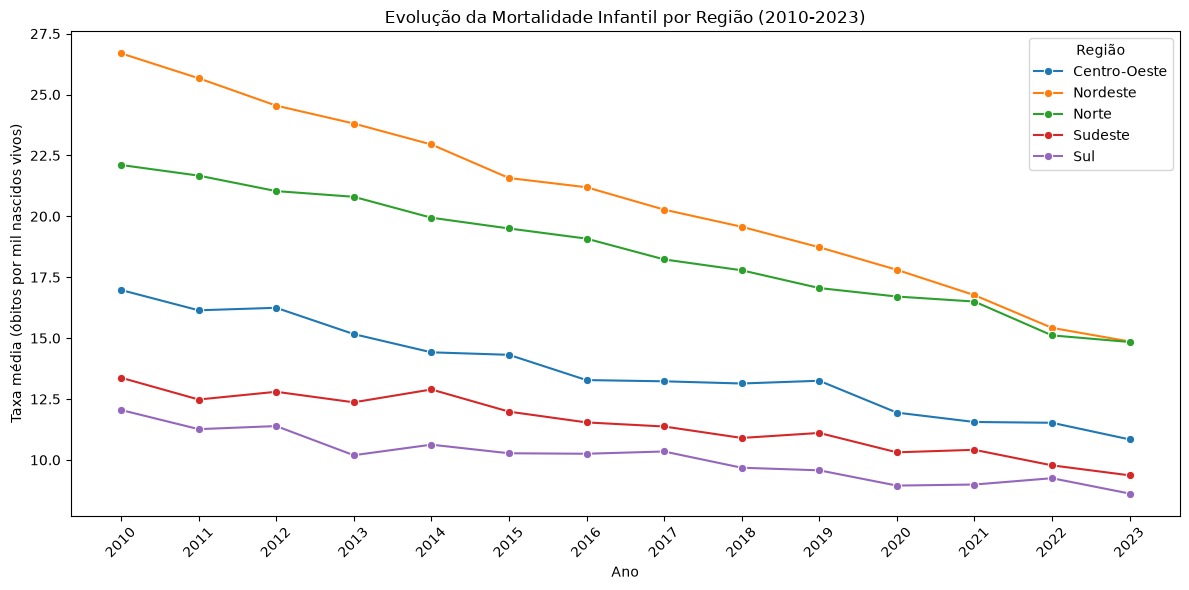

In [9]:
# ## Como cada região evoluiu ao longo dos anos?

media_regiao_ano = df.groupby(['ano', 'regiao'])['taxa_mortalidade_infantil'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=media_regiao_ano, x='ano', y='taxa_mortalidade_infantil', hue='regiao', marker='o')
plt.title('Evolução da Mortalidade Infantil por Região (2010-2023)')
plt.xlabel('Ano')
plt.ylabel('Taxa média (óbitos por mil nascidos vivos)')
plt.xticks(media_regiao_ano['ano'].unique(), rotation=45)
plt.legend(title='Região')
plt.tight_layout()
plt.savefig(r'C:\Users\Samsung\OneDrive\Documentos\faculdade\Análise Exploratória de Mortalidade Infantil no Brasil\imagens\evolucao_por_regiao.png')
plt.show()

CONCLUSÕES

- O Nordeste e Norte apresentaram as maiores taxas de mortalidade infantil no período
- O Brasil apresentou queda consistente entre 2010 e 2023, mostrando avanço nas políticas de saúde
- O Sul e Sudeste mantiveram as menores taxas ao longo de todo o período
- A desigualdade regional persiste, com o Nordeste tendo taxa quase 2x maior que o Sul